# 01. 대여소별 시간당 수요 예측
시간대별 자전거 대여 수요를 예측합니다 (회귀 문제).

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from src.data_loader import load_processed, save_processed
from src.feature_engineering import build_lag_features, complete_hourly_panel
from src.evaluation import regression_report, plot_actual_vs_predicted, plot_feature_importance

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

pd.set_option("display.float_format", "{:.3f}".format)
print("✅ 준비 완료")

✅ 준비 완료


## 1. 데이터 로드

In [2]:
hourly = load_processed("station_hourly_demand")
print(hourly.head())
print(f"\n대여소 수: {hourly['stn_id'].nunique():,}")
print(f"시간 범위: {hourly['datetime_hour'].min()} ~ {hourly['datetime_hour'].max()}")
print(f"\n대여 건수 통계:")
print(hourly["rent_count"].describe())

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)
  stn_id       datetime_hour  rent_count  rtrn_count  net_flow
0  ST-10 2025-10-01 00:00:00       0.000       3.000    -3.000
1  ST-10 2025-10-01 01:00:00       4.000       2.000     2.000
2  ST-10 2025-10-01 02:00:00       1.000       2.000    -1.000
3  ST-10 2025-10-01 03:00:00       1.000       1.000     0.000
4  ST-10 2025-10-01 04:00:00       2.000       0.000     2.000

대여소 수: 2,791
시간 범위: 2025-10-01 00:00:00 ~ 2025-12-31 23:00:00

대여 건수 통계:


count   3835657.000
mean          2.232
std           3.133
min           0.000
25%           1.000
50%           1.000
75%           3.000
max         164.000
Name: rent_count, dtype: float64


## 2. 상위 대여소 필터링 및 피처 엔지니어링

In [3]:
from src.feature_engineering import add_holiday_features, add_cyclical_features, complete_hourly_panel

# 상위 100개 대여소 선택 후, 누락 시간대를 0으로 채운 dense hourly panel 구성
top_stns = hourly.groupby("stn_id")["rent_count"].sum().nlargest(100).index
df_top = hourly[hourly["stn_id"].isin(top_stns)].copy()
df_panel = complete_hourly_panel(df_top, station_ids=top_stns)
print(f"상위 100개 대여소 원본 집계: {len(df_top):,}행")
print(f"dense hourly panel: {len(df_panel):,}행")

# 래그 피처 추가 (336h=2주, 720h=30일 포함)
df_feat = build_lag_features(df_panel, target_col="rent_count")

# 시간 피처
df_feat["hour"]       = df_feat["datetime_hour"].dt.hour
df_feat["dow"]        = df_feat["datetime_hour"].dt.dayofweek
df_feat["day"]        = df_feat["datetime_hour"].dt.day
df_feat["month"]      = df_feat["datetime_hour"].dt.month
df_feat["is_weekend"] = (df_feat["dow"] >= 5).astype(int)

# 공휴일 피처 (개천절, 한글날, 크리스마스)
df_feat = add_holiday_features(df_feat, dt_col="datetime_hour")

# 시간/요일 순환 인코딩
df_feat = add_cyclical_features(df_feat)

# 대여소 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_feat["stn_enc"] = le.fit_transform(df_feat["stn_id"])

# 래그 컬럼 결측치 제거
lag_cols = [c for c in df_feat.columns if c.startswith("lag_") or c.startswith("roll_")]
df_feat = df_feat.dropna(subset=lag_cols)

# net_flow 래그 피처 추가 (대여소별 순유출 과거값)
for lag in [1, 24, 168]:
    df_feat[f"net_flow_lag_{lag}h"] = df_feat.groupby("stn_id")["net_flow"].shift(lag)
netflow_cols = [f"net_flow_lag_{l}h" for l in [1, 24, 168]]
df_feat = df_feat.dropna(subset=netflow_cols)

print(f"피처 엔지니어링 후 사용 가능 행 수: {len(df_feat):,}행")
df_feat.head(3)

상위 100개 대여소 원본 집계: 196,759행
dense hourly panel: 220,800행
피처 엔지니어링 후 사용 가능 행 수: 132,000행


,stn_id,datetime_hour,rent_count,rtrn_count,net_flow,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,...,is_holiday,is_holiday_eve,hour_sin,hour_cos,dow_sin,dow_cos,stn_enc,net_flow_lag_1h,net_flow_lag_24h,net_flow_lag_168h
888,ST-1017,2025-11-07 00:00:00,0.000,2.000,-2.000,4.000,16.000,17.000,1.000,2.000,...,0,0,0.000,1.000,-0.434,-0.901,0,4.000,-2.000,1.000
889,ST-1017,2025-11-07 01:00:00,2.000,0.000,2.000,0.000,4.000,16.000,0.000,1.000,...,0,0,0.259,0.966,-0.434,-0.901,0,-2.000,0.000,1.000
890,ST-1017,2025-11-07 02:00:00,0.000,0.000,0.000,2.000,0.000,4.000,1.000,1.000,...,0,0,0.500,0.866,-0.434,-0.901,0,2.000,1.000,0.000


## 3. 학습/검증/테스트 분할 (시간순)

In [4]:
# 공통 시점 기준 시간순 분할: 같은 시점 이전은 train, 이후는 test
unique_times = sorted(df_feat["datetime_hour"].unique())
split_time = unique_times[int(len(unique_times) * 0.75)]
df_train = df_feat[df_feat["datetime_hour"] < split_time].copy()
df_test  = df_feat[df_feat["datetime_hour"] >= split_time].copy()

FEATURE_COLS = (
    ["stn_enc", "hour", "dow", "day", "month", "is_weekend"]
    + ["is_holiday", "is_holiday_eve"]
    + lag_cols
    + netflow_cols
)

X_train = df_train[FEATURE_COLS]
y_train = df_train["rent_count"]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test["rent_count"]

print(f"split 시점: {split_time}")
print(f"학습 데이터: {len(X_train):,}행  |  테스트: {len(X_test):,}행")
print(f"학습/테스트 대여소 수: {df_train['stn_id'].nunique()} / {df_test['stn_id'].nunique()}")
print(f"피처 수: {len(FEATURE_COLS)}")
print(f"시간 범위: {df_train['datetime_hour'].min()} ~ {df_test['datetime_hour'].max()}")

split 시점: 2025-12-18 06:00:00
학습 데이터: 99,000행  |  테스트: 33,000행
학습/테스트 대여소 수: 100 / 100
피처 수: 22
시간 범위: 2025-11-07 00:00:00 ~ 2025-12-31 23:00:00


## 4. 베이스라인 모델

In [5]:
# 베이스라인 1: 전체 평균
baseline_mean = np.full(len(y_test), y_train.mean())
r1 = regression_report(y_test, baseline_mean, "평균 예측")

# 베이스라인 2: 168시간 전 (1주일 전) 값 사용
lag168 = df_test["lag_168h"].fillna(y_train.mean())
r2 = regression_report(y_test, lag168, "7일전 래그")

print(f"\n베이스라인 비교: 평균 MAE={r1['MAE']:.3f}, 7일전래그 MAE={r2['MAE']:.3f}")

[평균 예측] MAE=3.851  RMSE=4.981  MAPE=150.1%  R²=-0.1560
[7일전 래그] MAE=2.515  RMSE=4.052  MAPE=94.3%  R²=0.2348

베이스라인 비교: 평균 MAE=3.851, 7일전래그 MAE=2.515


## 5. Ablation Study — 단계별 피처 추가

동일한 데이터/모델 구조에서 피처를 하나씩 추가하며 MAE 변화를 측정합니다.

| 단계 | 피처 구성 |
|---|---|
| Step 1 | 기본 (대여소, 시간, 요일, 월, 주말, 공휴일) |
| Step 2 | Step 1 + lag 피처 (1h~720h) + rolling mean |
| Step 3 | Step 2 + net_flow lag (1h, 24h, 168h) |
| Step 4 | Step 3 + 순환 인코딩 (hour_sin/cos, dow_sin/cos) |

In [6]:
LGBM_PARAMS = dict(
    objective="regression_l1",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

BASE_COLS      = ["stn_enc", "hour", "dow", "day", "month", "is_weekend",
                  "is_holiday", "is_holiday_eve"]
LAG_COLS       = [c for c in df_feat.columns if c.startswith("lag_") or c.startswith("roll_")]
NETFLOW_COLS   = [f"net_flow_lag_{l}h" for l in [1, 24, 168]]
CYCLICAL_COLS  = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

steps = [
    ("Step 1: 기본",                BASE_COLS),
    ("Step 2: + lag",               BASE_COLS + LAG_COLS),
    ("Step 3: + net_flow lag",      BASE_COLS + LAG_COLS + NETFLOW_COLS),
    ("Step 4: + 순환 인코딩",        BASE_COLS + LAG_COLS + NETFLOW_COLS + CYCLICAL_COLS),
]

ablation_results = []

for name, feat_cols in steps:
    m = lgb.LGBMRegressor(**LGBM_PARAMS)
    m.fit(
        df_train[feat_cols], y_train,
        eval_set=[(df_test[feat_cols], y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    pred = m.predict(df_test[feat_cols]).clip(0)
    mae  = mean_absolute_error(y_test, pred)
    ablation_results.append({"단계": name, "MAE": round(mae, 3), "피처 수": len(feat_cols)})
    print(f"{name:<30}  피처 수={len(feat_cols):>3}  MAE={mae:.3f}")

abl_df = pd.DataFrame(ablation_results)
abl_df["MAE 개선"] = abl_df["MAE"].diff().map(lambda x: f"{x:+.3f}" if pd.notna(x) else "-")
abl_df["개선율(%)"] = (
    (abl_df["MAE"].shift(1) - abl_df["MAE"]) / abl_df["MAE"].shift(1) * 100
).map(lambda x: f"{x:.1f}%" if pd.notna(x) else "-")
print("\n📊 Ablation Study 결과:")
print(abl_df.to_string(index=False))

Step 1: 기본                      피처 수=  8  MAE=2.069


Step 2: + lag                   피처 수= 19  MAE=1.748


Step 3: + net_flow lag          피처 수= 22  MAE=1.698


Step 4: + 순환 인코딩                피처 수= 26  MAE=1.701

📊 Ablation Study 결과:
                    단계   MAE  피처 수 MAE 개선 개선율(%)
            Step 1: 기본 2.069     8      -      -
         Step 2: + lag 1.748    19 -0.321  15.5%
Step 3: + net_flow lag 1.698    22 -0.050   2.9%
      Step 4: + 순환 인코딩 1.701    26 +0.003  -0.2%


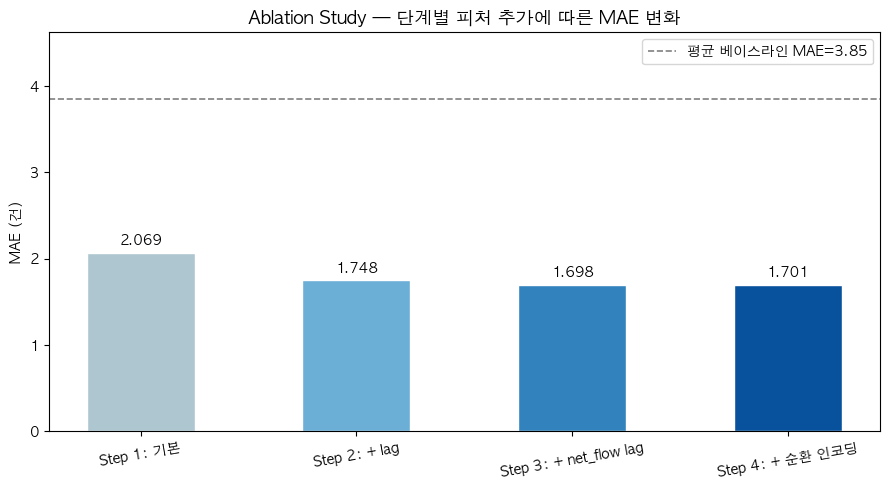

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#aec6cf", "#6baed6", "#3182bd", "#08519c"]
bars = ax.bar(abl_df["단계"], abl_df["MAE"], color=colors, edgecolor="white", width=0.5)

# 베이스라인(평균 예측) 수평선
ax.axhline(r1["MAE"], color="gray", linestyle="--", linewidth=1.2, label=f"평균 베이스라인 MAE={r1['MAE']:.2f}")

# 각 막대 위에 MAE 값 표시
for bar, row in zip(bars, abl_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{row.MAE:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Ablation Study — 단계별 피처 추가에 따른 MAE 변화", fontsize=13)
ax.set_ylabel("MAE (건)")
ax.set_ylim(0, r1["MAE"] * 1.2)
ax.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("../reports/figures/ablation_mae.png", dpi=150)
plt.show()

## 5. LightGBM 모델

In [8]:
model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

y_pred = model.predict(X_test).clip(0)
r3 = regression_report(y_test, y_pred, "LightGBM")
print(f"\n개선율 vs 평균 베이스라인: MAE {(1 - r3['MAE']/r1['MAE'])*100:.1f}% 향상")

[100]	valid_0's l1: 1.70785


[200]	valid_0's l1: 1.69829


[LightGBM] MAE=1.698  RMSE=2.641  MAPE=57.4%  R²=0.6750

개선율 vs 평균 베이스라인: MAE 55.9% 향상


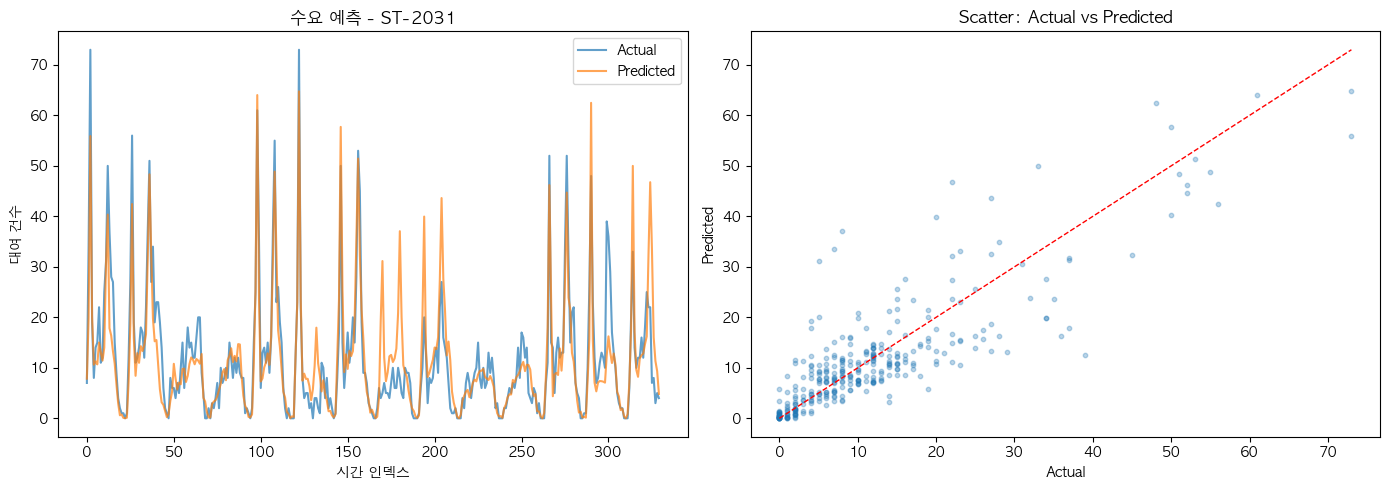

In [9]:
# 테스트셋에서 수요 합계가 가장 큰 대여소를 대표 예시로 시각화
stn_sample = df_test.groupby("stn_id")["rent_count"].sum().idxmax()
mask = df_test["stn_id"] == stn_sample
y_true_stn = y_test[mask].values
y_pred_stn = y_pred[mask]

plot_actual_vs_predicted(
    y_true_stn, y_pred_stn,
    title=f"수요 예측 - {stn_sample}",
    xlabel="시간 인덱스",
    ylabel="대여 건수",
    save_name="demand_forecast_sample"
)

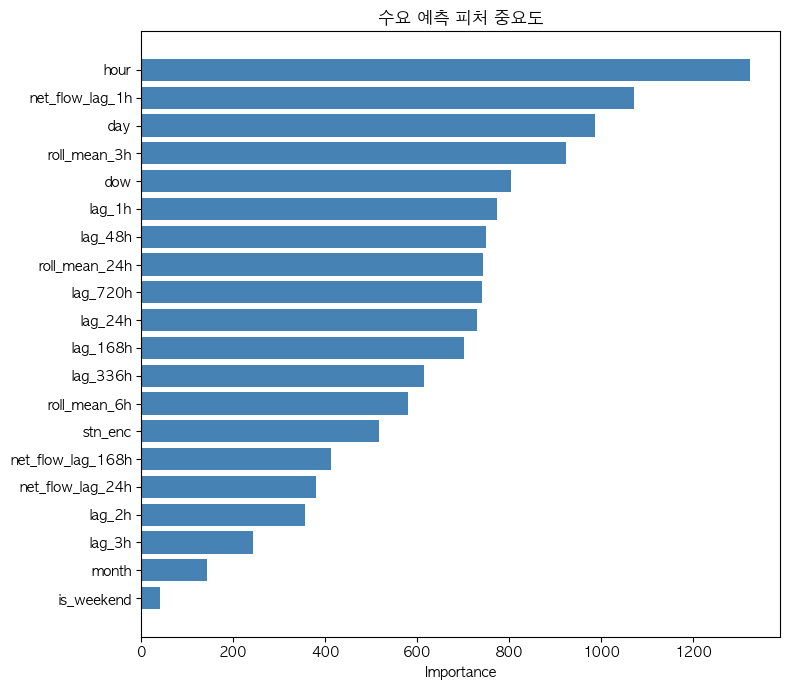

In [10]:
plot_feature_importance(
    model, FEATURE_COLS,
    title="수요 예측 피처 중요도",
    save_name="demand_feature_importance"
)

## 시각화: 베이스라인 vs LightGBM 수요 예측 비교

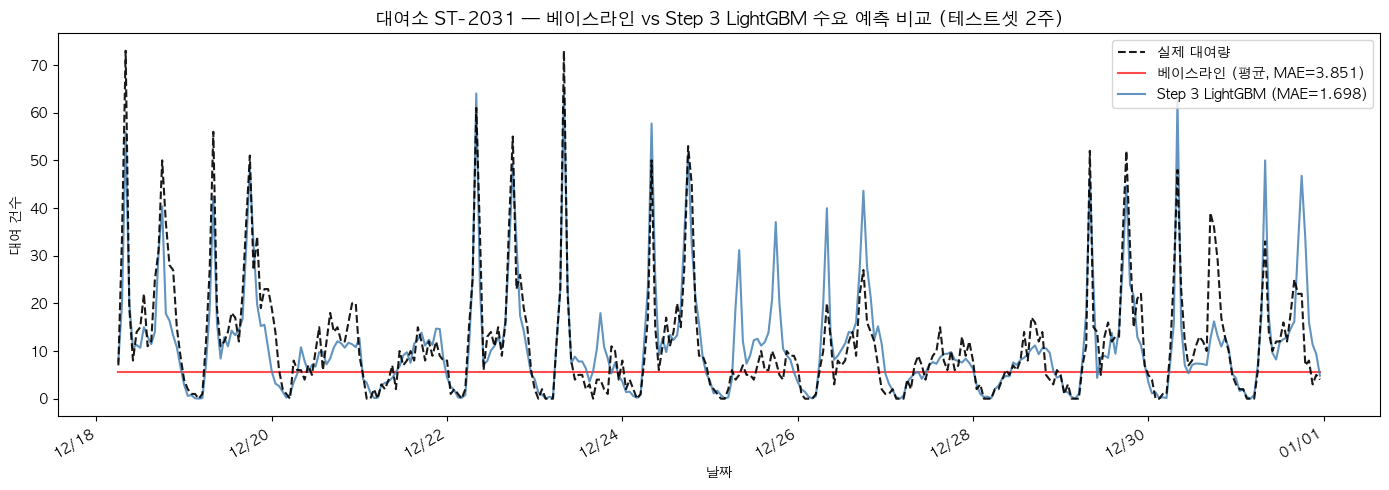

전체 테스트셋 MAE — 베이스라인: 3.851  LightGBM: 1.698


In [11]:
import matplotlib.dates as mdates

# df_test에 예측값 결합
df_vis = df_test[["stn_id", "datetime_hour", "rent_count"]].copy().reset_index(drop=True)
df_vis["y_actual"]   = np.array(y_test)
df_vis["y_baseline"] = float(y_train.mean())   # 평균 베이스라인 (수평선)
df_vis["y_lgbm"]     = np.array(y_pred)

# 테스트셋 내 대여량 합계 최다 대여소 선택
top_vis_stn = df_vis.groupby("stn_id")["y_actual"].sum().idxmax()
stn_df = df_vis[df_vis["stn_id"] == top_vis_stn].sort_values("datetime_hour").reset_index(drop=True)
n = min(336, len(stn_df))   # 최대 2주(336시간) 표시

mae_base = round(float(np.mean(np.abs(df_vis["y_actual"] - df_vis["y_baseline"]))), 3)
mae_lgbm = round(float(np.mean(np.abs(df_vis["y_actual"] - df_vis["y_lgbm"]))), 3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_actual"][:n],
        linestyle="--", color="black",     linewidth=1.5, label="실제 대여량",                  alpha=0.9, zorder=3)
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_baseline"][:n],
        color="red",       linewidth=1.5, label=f"베이스라인 (평균, MAE={mae_base})", alpha=0.7, zorder=2)
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_lgbm"][:n],
        color="steelblue", linewidth=1.5, label=f"Step 3 LightGBM (MAE={mae_lgbm})", alpha=0.85, zorder=2)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_title(f"대여소 {top_vis_stn} — 베이스라인 vs Step 3 LightGBM 수요 예측 비교 (테스트셋 2주)", fontsize=13)
ax.set_xlabel("날짜")
ax.set_ylabel("대여 건수")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../reports/figures/demand_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"전체 테스트셋 MAE — 베이스라인: {mae_base}  LightGBM: {mae_lgbm}")

## 6. 모델 저장

In [12]:
from pathlib import Path
import joblib

model_path = Path("../models/demand/lgbm_demand.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"✅ 모델 저장: {model_path}")

# 결과 요약
results = pd.DataFrame([r1, r2, r3], index=["평균 베이스라인", "7일전 래그", "LightGBM"])
print("\n📊 모델 성능 비교:")
print(results.round(4))

✅ 모델 저장: ../models/demand/lgbm_demand.pkl

📊 모델 성능 비교:
           MAE  RMSE  MAPE(%)     R²
평균 베이스라인 3.851 4.981  150.144 -0.156
7일전 래그   2.515 4.052   94.266  0.235
LightGBM 1.698 2.641   57.365  0.675
